<a href="https://colab.research.google.com/github/afllaabdi/tugas_data_mining/blob/main/PenggalianData.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. MOUNT GOOGLE DRIVE

In [ ]:
# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans

Mounted at /content/drive


3. LOAD DATASET

In [ ]:
path = '/content/drive/MyDrive/dataset/wfp_food_prices_idn.csv'
df = pd.read_csv(path)

print("=== DATA AWAL ===")
print(df.head())

=== DATA AWAL ===
         date      admin1      admin2            market  latitude longitude  \
0       #date  #adm1+name  #adm2+name  #loc+market+name  #geo+lat  #geo+lon   
1  2007-01-15         NaN         NaN  National Average       NaN       NaN   
2  2007-01-15         NaN         NaN  National Average       NaN       NaN   
3  2007-01-15         NaN         NaN  National Average       NaN       NaN   
4  2007-01-15         NaN         NaN  National Average       NaN       NaN   

              category    commodity        unit         priceflag  \
0           #item+type   #item+name  #item+unit  #item+price+flag   
1   cereals and tubers         Rice          KG            actual   
2   cereals and tubers  Wheat flour          KG            actual   
3  meat, fish and eggs         Eggs          KG            actual   
4  meat, fish and eggs  Meat (beef)          KG            actual   

          pricetype   currency     price    usdprice  
0  #item+price+type  #currency    #va

/tmp/ipykernel_736/3469313730.py:2: DtypeWarning: Columns (4,5,12,13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


4. CEK STRUKTUR DATA

In [ ]:
print("\n=== INFO DATA ===")
print(df.info())

print("\n=== MISSING VALUE ===")
print(df.isnull().sum())


=== INFO DATA ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264564 entries, 0 to 264563
Data columns (total 14 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   date       264564 non-null  object
 1   admin1     262901 non-null  object
 2   admin2     262901 non-null  object
 3   market     264564 non-null  object
 4   latitude   262901 non-null  object
 5   longitude  262901 non-null  object
 6   category   264564 non-null  object
 7   commodity  264564 non-null  object
 8   unit       264564 non-null  object
 9   priceflag  264564 non-null  object
 10  pricetype  264564 non-null  object
 11  currency   264564 non-null  object
 12  price      264564 non-null  object
 13  usdprice   264564 non-null  object
dtypes: object(14)
memory usage: 28.3+ MB
None

=== MISSING VALUE ===
date            0
admin1       1663
admin2       1663
market          0
latitude     1663
longitude    1663
category        0
commodity       0
unit            

5. DATA CLEANING

In [ ]:
# Hapus data tidak valid
df = df[df['date'] != '#date']

# Convert date ke datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Hapus data invalid & missing
df = df.dropna()

# Hapus duplikat
df = df.drop_duplicates()

print("\n=== SETELAH CLEANING ===")
print(df.shape)




=== SETELAH CLEANING ===
(262900, 14)


In [ ]:
# Pastikan price numeric
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# Hapus yang gagal convert
df = df.dropna(subset=['price'])

6.DATA TRANSFORMATION

In [ ]:
# Ekstrak fitur waktu
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

print("\n=== TRANSFORMASI DATE ===")
print(df[['date', 'year', 'month']].head())

# Pastikan price numeric
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# Hapus yang gagal convert
df = df.dropna(subset=['price'])



=== TRANSFORMASI DATE ===
           date  year  month
1664 2016-07-15  2016      7
1665 2016-07-15  2016      7
1666 2016-07-15  2016      7
1667 2016-07-15  2016      7
1668 2016-07-15  2016      7


7.FEATURE SELECTION

In [ ]:
df = df[['year', 'month', 'admin1', 'market', 'category', 'commodity', 'price']]

print("\n=== DATA SETELAH FEATURE SELECTION ===")
print(df.head())



=== DATA SETELAH FEATURE SELECTION ===
      year  month admin1           market             category  \
1664  2016      7   ACEH  Pasar Peunayong   cereals and tubers   
1665  2016      7   ACEH  Pasar Peunayong   cereals and tubers   
1666  2016      7   ACEH  Pasar Peunayong   cereals and tubers   
1667  2016      7   ACEH  Pasar Peunayong  meat, fish and eggs   
1668  2016      7   ACEH  Pasar Peunayong  meat, fish and eggs   

                commodity     price  
1664                 Rice   9589.29  
1665  Rice (high quality)  10266.07  
1666   Rice (low quality)   9166.07  
1667                 Eggs  22371.43  
1668       Eggs (broiler)  22371.43  


8.ENCODING

In [ ]:
le = LabelEncoder()

categorical_cols = ['admin1', 'market', 'category', 'commodity']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print("\n=== DATA SETELAH ENCODING ===")
print(df.head(20))


=== DATA SETELAH ENCODING ===
      year  month  admin1  market  category  commodity      price
1664  2016      7       0     152         0         20    9589.29
1665  2016      7       0     152         0         21   10266.07
1666  2016      7       0     152         0         22    9166.07
1667  2016      7       0     152         1          6   22371.43
1668  2016      7       0     152         1          7   22371.43
1669  2016      7       0     152         1         10  130000.00
1670  2016      7       0     152         1         11  130000.00
1671  2016      7       0     152         1         13   31964.29
1672  2016      7       0     152         1         14   31964.29
1673  2016      7       0     152         2         24   18714.29
1674  2016      7       0     152         2         25   17928.57
1675  2016      7       0     152         2         26   19500.00
1676  2016      7       0     152         3         15   13607.14
1677  2016      7       0     152         3  

9.VISUALISASI

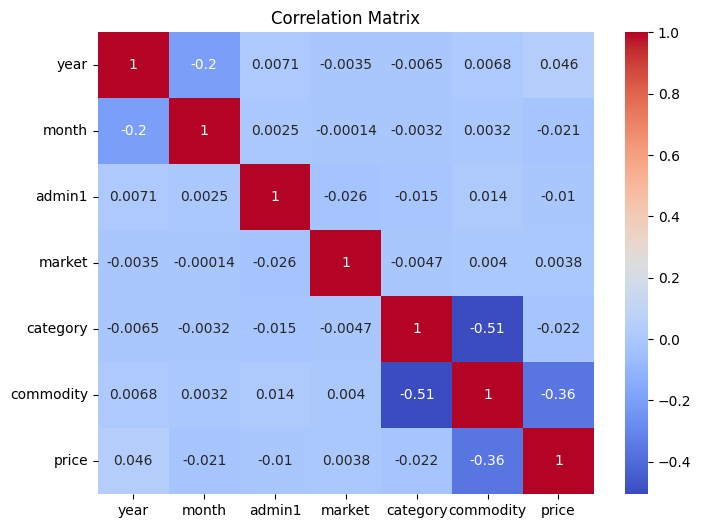

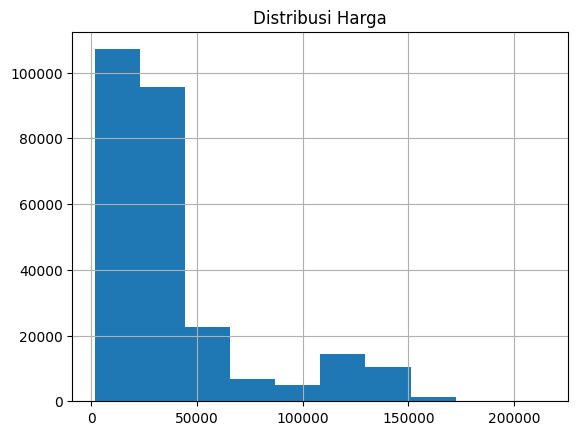

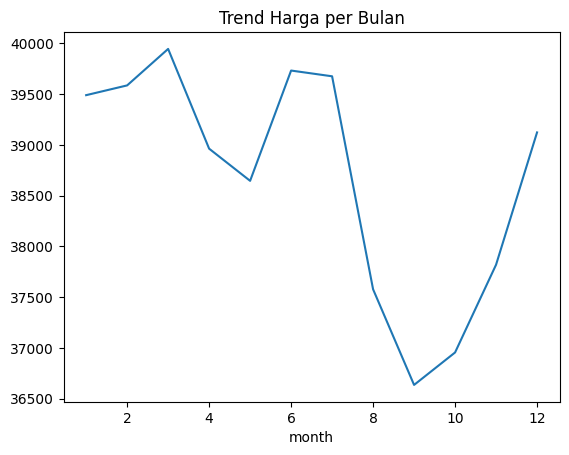

In [ ]:
# Korelasi
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# Distribusi harga
plt.figure()
df['price'].hist()
plt.title("Distribusi Harga")
plt.show()

# Trend harga
plt.figure()
df.groupby('month')['price'].mean().plot()
plt.title("Trend Harga per Bulan")
plt.show()

In [ ]:
# Simpan dataset setelah cleaning
clean_path = '/content/drive/MyDrive/dataset/cleaned_data.csv'
df.to_csv(clean_path, index=False)

print("Dataset berhasil disimpan di:", clean_path)

Dataset berhasil disimpan di: /content/drive/MyDrive/dataset/cleaned_data.csv
